In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import Exponential
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class PassDecisionNetwork(nn.Module):
    def __init__(self, hidden_dim=16):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # Pass region (AP) - learns identity function
        self.pass_gru = nn.GRU(input_size=2, hidden_size=hidden_dim, batch_first=True)
        self.pass_readout = nn.Linear(hidden_dim, 2)  # Output stimulus
        
        # Decision region (AD) - integrates signal
        self.decision_gru = nn.GRU(input_size=2, hidden_size=hidden_dim, batch_first=True)
        self.decision_readout = nn.Linear(hidden_dim, 1)  # Output decision variable
        
        # Communication from pass to decision
        self.comm_layer = nn.Linear(2, 2)  # Pass stimulus to decision
        
        self.to(device)
    
    def forward(self, stimulus, return_states=False):
        batch_size, seq_len, _ = stimulus.shape
        
        # Initialize hidden states
        h_pass = torch.zeros(1, batch_size, self.hidden_dim, device=device)
        h_decision = torch.zeros(1, batch_size, self.hidden_dim, device=device)
        
        pass_outputs = []
        decision_outputs = []
        communications = []
        decision_vars = []
        
        for t in range(seq_len):
            # Pass region receives stimulus and learns identity
            pass_out, h_pass = self.pass_gru(stimulus[:, t:t+1], h_pass)
            pass_output = self.pass_readout(pass_out.squeeze(1))
            pass_outputs.append(pass_output)
            
            # Communication: pass sends stimulus to decision
            comm_signal = self.comm_layer(pass_output)
            communications.append(comm_signal)
            
            # Decision region receives communication and integrates
            decision_out, h_decision = self.decision_gru(comm_signal.unsqueeze(1), h_decision)
            decision_output = self.decision_readout(decision_out.squeeze(1))
            decision_outputs.append(decision_output)
            
            # Decision variable accumulates over time
            if t == 0:
                decision_var = decision_output
            else:
                decision_var = decision_vars[-1] + decision_output
            decision_vars.append(decision_var)
        
        pass_outputs = torch.stack(pass_outputs, dim=1)
        decision_outputs = torch.stack(decision_outputs, dim=1)
        communications = torch.stack(communications, dim=1)
        decision_vars = torch.stack(decision_vars, dim=1)
        
        if return_states:
            return {
                'pass_outputs': pass_outputs,
                'decision_outputs': decision_outputs,
                'communications': communications,
                'decision_vars': decision_vars
            }
        
        return pass_outputs, decision_vars

def generate_pass_decision_data(n_trials=500, seq_len=100):
    """Generate data for pass-decision task"""
    data = []
    
    for trial in range(n_trials):
        # Generate stimulus sequence
        stimulus = torch.zeros(seq_len, 2)
        
        # Sample fewer, more sparse stimuli for clearer signal
        n_stimuli = torch.poisson(torch.tensor(3.0)).int().item()
        stim_times = torch.randint(5, seq_len-5, (n_stimuli,))
        
        for t in stim_times:
            # Smaller stimulus values for better learning
            stim_val = torch.rand(2) * 2 + 0.5  # Range [0.5, 2.5]
            stimulus[t] = stim_val
        
        # Ground truth targets
        pass_target = stimulus.clone()  # Identity function
        
        # Decision variable (cumulative sum of stimulus magnitude)
        decision_target = torch.cumsum(stimulus.sum(dim=1, keepdim=True), dim=0)
        
        data.append({
            'stimulus': stimulus,
            'pass_target': pass_target,
            'decision_target': decision_target,
            'communication_target': stimulus  # Ground truth communication
        })
    
    return data

def create_batched_data(data, batch_size=32):
    """Convert list of trials to batched tensors"""
    stimuli = torch.stack([d['stimulus'] for d in data])
    pass_targets = torch.stack([d['pass_target'] for d in data])
    decision_targets = torch.stack([d['decision_target'] for d in data])
    
    batches = []
    for i in range(0, len(data), batch_size):
        batch = {
            'stimulus': stimuli[i:i+batch_size].to(device),
            'pass_target': pass_targets[i:i+batch_size].to(device),
            'decision_target': decision_targets[i:i+batch_size].to(device)
        }
        batches.append(batch)
    
    return batches

def train_pass_decision_network(model, data, n_epochs=200, lr=1e-3, batch_size=32):
    """Train the pass-decision network with proper batching"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr*5, epochs=n_epochs, 
                                            steps_per_epoch=len(data)//batch_size + 1)
    model.train()
    
    # Create batched data once
    batched_data = create_batched_data(data, batch_size)
    
    losses = []
    for epoch in tqdm(range(n_epochs), desc="Training"):
        total_loss = 0
        
        for batch in batched_data:
            optimizer.zero_grad()
            
            # Forward pass on entire batch
            pass_out, decision_var = model(batch['stimulus'])
            
            # Compute losses
            pass_loss = nn.MSELoss()(pass_out, batch['pass_target'])
            decision_loss = nn.MSELoss()(decision_var, batch['decision_target'])
            
            # Total loss
            loss = pass_loss + decision_loss
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(batched_data)
        losses.append(avg_loss)
        
        if epoch % 50 == 0:
            tqdm.write(f"Epoch {epoch}, Loss: {avg_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.2e}")
    
    model.eval()
    return losses

def plot_network_activity(model, test_data, trial_idx=0):
    """Plot network activity for visualization"""
    model.eval()
    
    with torch.no_grad():
        trial_data = test_data[trial_idx]
        stimulus = trial_data['stimulus'].unsqueeze(0).to(device)
        
        # Get network outputs
        results = model(stimulus, return_states=True)
        
        # Convert to numpy for plotting
        stimulus_np = stimulus.squeeze().cpu().numpy()
        pass_out = results['pass_outputs'].squeeze().cpu().numpy()
        comm = results['communications'].squeeze().cpu().numpy()
        decision_var = results['decision_vars'].squeeze().cpu().numpy()
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        
        # Plot stimulus
        axes[0,0].plot(stimulus_np[:, 0], label='Stimulus Ch 1', color='red')
        axes[0,0].plot(stimulus_np[:, 1], label='Stimulus Ch 2', color='orange')
        axes[0,0].set_title('Input Stimulus')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # Plot pass region output
        axes[0,1].plot(pass_out[:, 0], label='Pass Out Ch 1', color='blue')
        axes[0,1].plot(pass_out[:, 1], label='Pass Out Ch 2', color='cyan')
        axes[0,1].plot(stimulus_np[:, 0], '--', alpha=0.5, label='True Ch 1', color='red')
        axes[0,1].plot(stimulus_np[:, 1], '--', alpha=0.5, label='True Ch 2', color='orange')
        axes[0,1].set_title('Pass Region Output (Identity)')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # Plot communication
        axes[1,0].plot(comm[:, 0], label='Comm Ch 1', color='green')
        axes[1,0].plot(comm[:, 1], label='Comm Ch 2', color='lime')
        axes[1,0].set_title('Communication P→D')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # Plot decision variable
        axes[1,1].plot(decision_var.flatten(), label='Decision Variable', color='purple')
        axes[1,1].plot(trial_data['decision_target'].flatten(), '--', 
                      alpha=0.7, label='True Decision Var', color='magenta')
        axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
        axes[1,1].set_title('Decision Variable (Integration)')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

def analyze_network_performance(model, test_data):
    """Analyze network performance on different metrics"""
    model.eval()
    
    pass_errors = []
    decision_errors = []
    comm_errors = []
    
    with torch.no_grad():
        for trial_data in test_data[:50]:  # Analyze first 50 trials
            stimulus = trial_data['stimulus'].unsqueeze(0).to(device)
            
            results = model(stimulus, return_states=True)
            
            # Pass region error (identity function)
            pass_error = nn.MSELoss()(
                results['pass_outputs'].squeeze(),
                trial_data['stimulus'].to(device)
            ).item()
            pass_errors.append(pass_error)
            
            # Decision variable error
            decision_error = nn.MSELoss()(
                results['decision_vars'].squeeze(),
                trial_data['decision_target'].squeeze().to(device)
            ).item()
            decision_errors.append(decision_error)
            
            # Communication error (should match stimulus)
            comm_error = nn.MSELoss()(
                results['communications'].squeeze(),
                trial_data['stimulus'].to(device)
            ).item()
            comm_errors.append(comm_error)
    
    print("=== Network Performance Analysis ===")
    print(f"Pass Region MSE (Identity): {np.mean(pass_errors):.6f} ± {np.std(pass_errors):.6f}")
    print(f"Decision Region MSE: {np.mean(decision_errors):.6f} ± {np.std(decision_errors):.6f}")
    print(f"Communication MSE: {np.mean(comm_errors):.6f} ± {np.std(comm_errors):.6f}")
    
    return {
        'pass_errors': pass_errors,
        'decision_errors': decision_errors,
        'comm_errors': comm_errors
    }

# torch.manual_seed(42)
# np.random.seed(42)

# print("Generating pass-decision network data...")
# train_data = generate_pass_decision_data(n_trials=800, seq_len=100)
# test_data = generate_pass_decision_data(n_trials=200, seq_len=100)

# print("Creating and training network...")
# model = PassDecisionNetwork(hidden_dim=16)

# print(f"Training on {device}...")
# losses = train_pass_decision_network(model, train_data, n_epochs=100, lr=1e-3, batch_size=64)

# # Plot training curve
# plt.figure(figsize=(8, 4))
# plt.plot(losses)
# plt.title('Training Loss')
# plt.xlabel('Epoch')
# plt.ylabel('MSE Loss')
# plt.yscale('log')
# plt.grid(True, alpha=0.3)
# plt.show()

# print("Analyzing network performance...")
# performance = analyze_network_performance(model, test_data)

# print("Plotting example trial...")
# plot_network_activity(model, test_data, trial_idx=5)
    
# print(f"Final training loss: {losses[-1]:.6f}")

Using device: cuda
Loading cached model and losses...
Loaded model with 200 training epochs


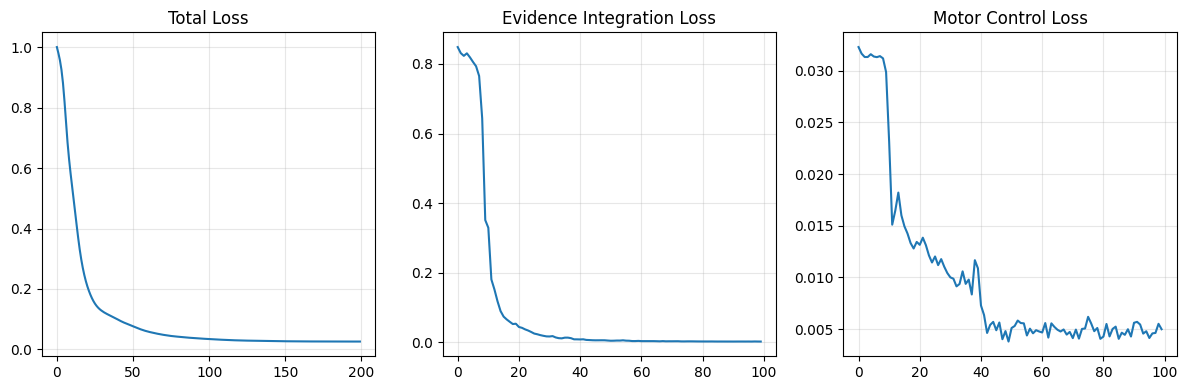

Analyzing your trained model...
Extracting trajectories from trained model...

Analyzing Evidence Region...
Evidence PCA explained variance: [0.8472559  0.10136481 0.02707326]


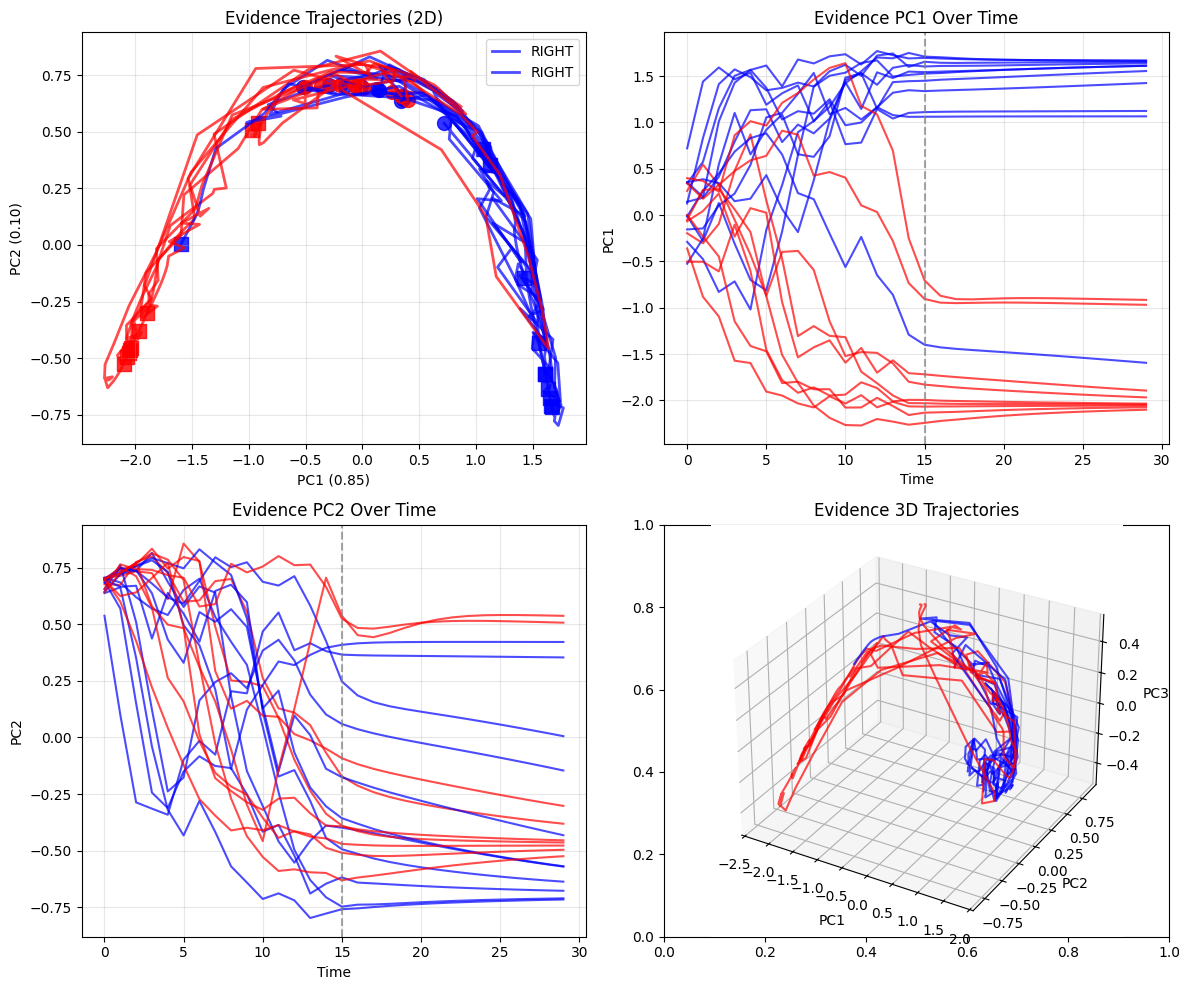


Analyzing Motor Region...
Motor PCA explained variance: [0.36518323 0.31394324 0.20328416]


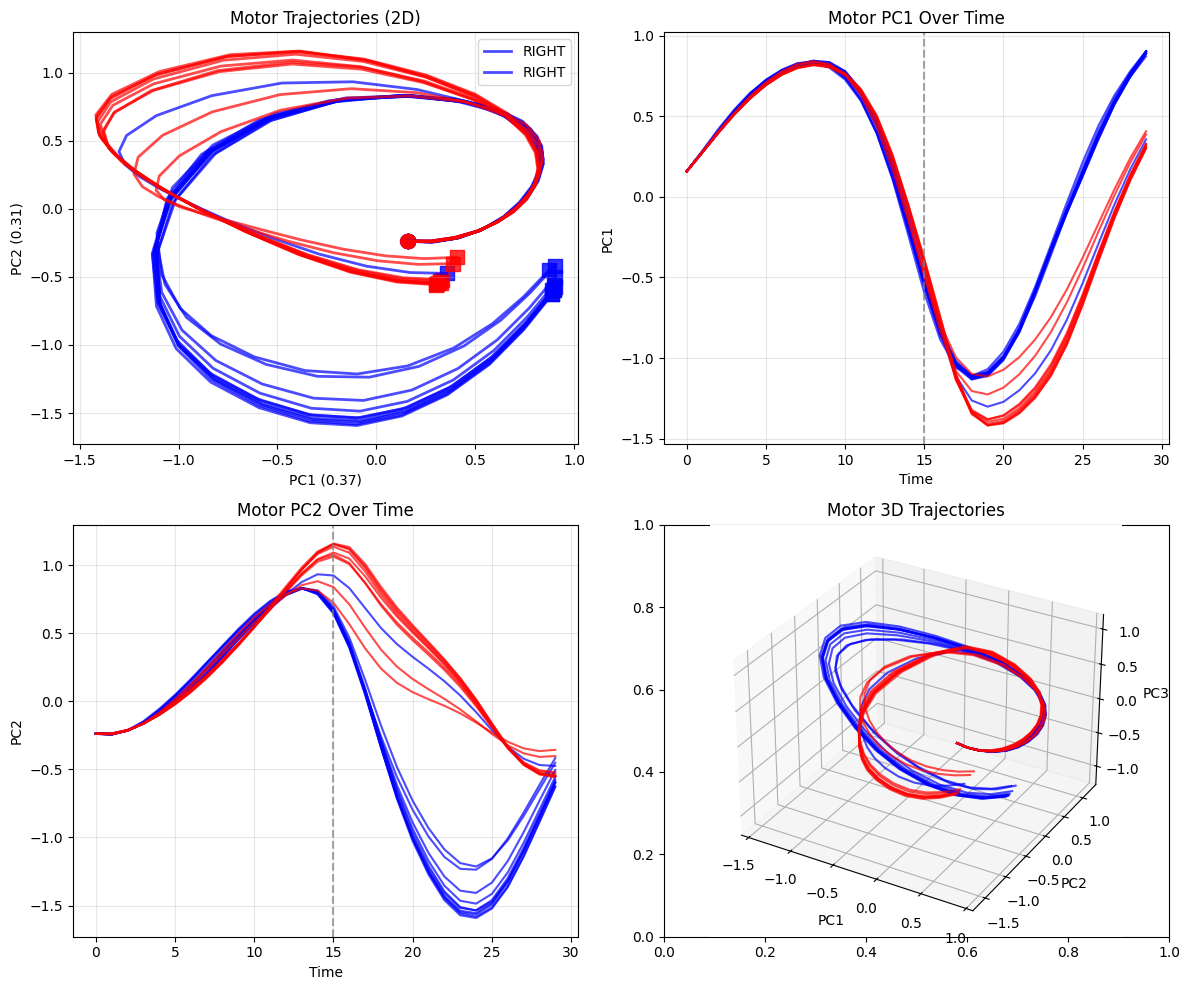


Analyzing Communication...


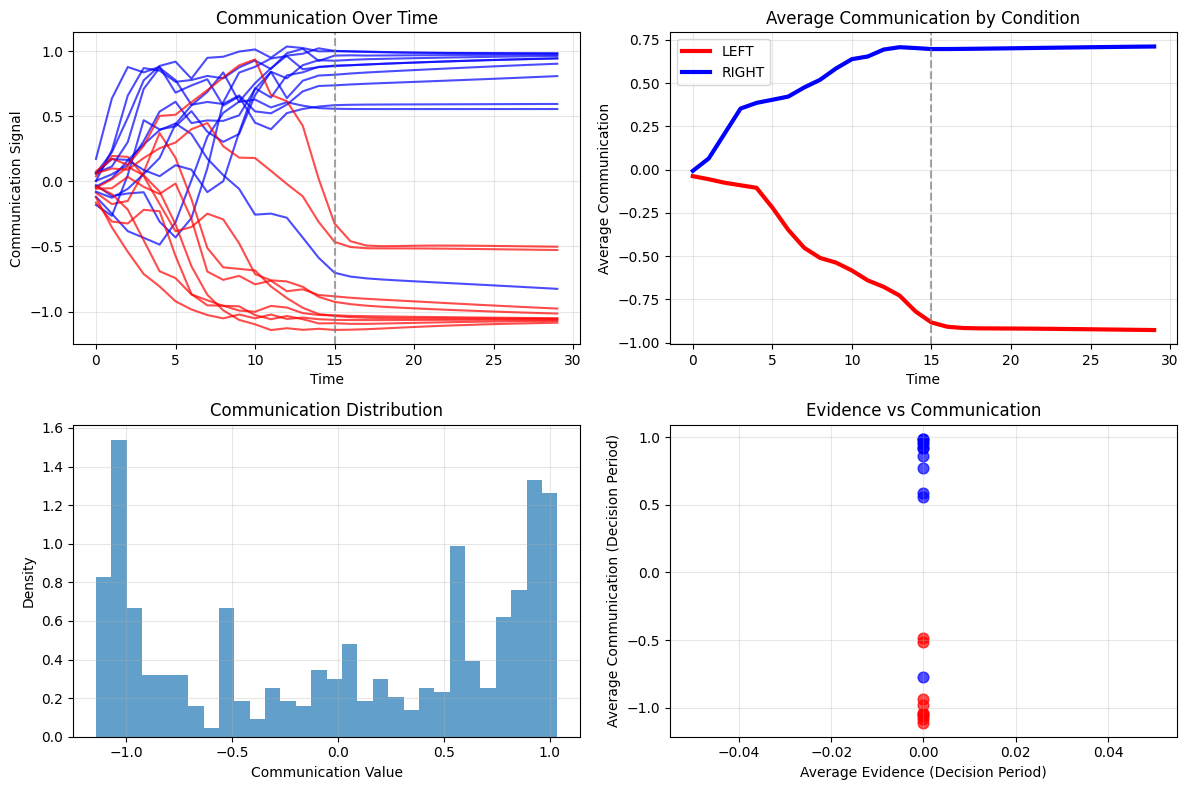

Training complete! Model saved as 'trained_model'


In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns


# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Task parameters
SEQUENCE_LENGTH = 30
EVIDENCE_PHASE = 15  # First 40 steps have evidence
RESPONSE_STEP = 29   # Must be correct at step 49
BATCH_SIZE = 128
N_TRIALS = 1000
COHERENCE = 0.8      # Evidence strength
NOISE_LEVEL = 0.5    # Evidence noise

def generate_task_data(batch_size, sequence_length, coherence=0.3, noise_level=0.5):
    """Generate evidence integration + reaching task data"""
    
    # Random target direction for each trial (0=LEFT, 1=RIGHT)
    targets = torch.randint(0, 2, (batch_size,), device=device)
    
    # Evidence streams (first 40 timesteps)
    evidence = torch.zeros(batch_size, sequence_length, 2, device=device)
    evidence[:, :EVIDENCE_PHASE, 0] = (1 - targets.float()).unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    evidence[:, :EVIDENCE_PHASE, 1] = targets.float().unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    
    # True evidence integration (teaching signal for Region 1)
    true_integration = torch.cumsum(evidence[:, :, 1] - evidence[:, :, 0], dim=1)
    true_integration = torch.tanh(true_integration)  # Bounded integration
    
    # Target reach trajectories (teaching signal for Region 2)
    target_positions = torch.zeros(batch_size, sequence_length, 2, device=device)
    target_velocities = torch.zeros(batch_size, sequence_length, 2, device=device)
    
    for i in range(batch_size):
        if targets[i] == 0:  # LEFT reach
            target_positions[i, :, 0] = -1.0  # x = -1
            target_positions[i, :, 1] = 0.0   # y = 0
        else:  # RIGHT reach  
            target_positions[i, :, 0] = 1.0   # x = 1
            target_positions[i, :, 1] = 0.0   # y = 0
    
    # Smooth velocity trajectories (start moving after evidence phase)
    for t in range(EVIDENCE_PHASE, sequence_length):
        progress = (t - EVIDENCE_PHASE) / (sequence_length - EVIDENCE_PHASE)
        smooth_vel = 0.5 * np.sin(np.pi * progress) if progress < 1.0 else 0.0
        
        for i in range(batch_size):
            if targets[i] == 0:  # LEFT
                target_velocities[i, t, 0] = -smooth_vel
            else:  # RIGHT
                target_velocities[i, t, 0] = smooth_vel
    
    return {
        'evidence': evidence,
        'targets': targets,
        'true_integration': true_integration,
        'target_positions': target_positions,
        'target_velocities': target_velocities
    }

class MultiRegionRNN(nn.Module):
    def __init__(self, evidence_hidden=64, motor_hidden=64):
        super().__init__()
        
        # Region 1: Evidence Integrator
        self.evidence_rnn = nn.LSTM(
            input_size=2,  # [evidence_left, evidence_right]
            hidden_size=evidence_hidden,
            batch_first=True
        )
        self.evidence_output = nn.Linear(evidence_hidden, 1)  # Integrated evidence
        
        # Region 2: Motor Controller  
        self.motor_rnn = nn.LSTM(
            input_size=3,  # [communication_from_R1, position_x, position_y]
            hidden_size=motor_hidden,
            batch_first=True
        )
        self.motor_output = nn.Linear(motor_hidden, 2)  # [velocity_x, velocity_y]
        
        # Communication layer (Region 1 → Region 2)
        self.communication = nn.Linear(evidence_hidden, 1)
        
        self.evidence_hidden_size = evidence_hidden
        self.motor_hidden_size = motor_hidden
        
    def forward(self, evidence_input):
        batch_size, seq_len, _ = evidence_input.shape
        
        # Initialize motor state
        motor_position = torch.zeros(batch_size, seq_len, 2, device=evidence_input.device)
        motor_velocity = torch.zeros(batch_size, seq_len, 2, device=evidence_input.device)
        
        # Storage for outputs
        evidence_outputs = []
        motor_outputs = []
        communications = []
        
        # Initialize hidden states
        evidence_hidden = (torch.zeros(1, batch_size, self.evidence_hidden_size, device=evidence_input.device),
                          torch.zeros(1, batch_size, self.evidence_hidden_size, device=evidence_input.device))
        motor_hidden = (torch.zeros(1, batch_size, self.motor_hidden_size, device=evidence_input.device),
                       torch.zeros(1, batch_size, self.motor_hidden_size, device=evidence_input.device))
        
        for t in range(seq_len):
            # Region 1: Evidence Integration
            evidence_out, evidence_hidden = self.evidence_rnn(
                evidence_input[:, t:t+1, :], evidence_hidden
            )
            integrated_evidence = self.evidence_output(evidence_out.squeeze(1))
            evidence_outputs.append(integrated_evidence)
            
            # Communication: Region 1 → Region 2
            comm_signal = self.communication(evidence_out.squeeze(1))
            communications.append(comm_signal)
            
            # Region 2: Motor Control
            motor_input = torch.cat([
                comm_signal,
                motor_position[:, t, :]
            ], dim=1).unsqueeze(1)
            
            motor_out, motor_hidden = self.motor_rnn(motor_input, motor_hidden)
            velocity_output = torch.tanh(self.motor_output(motor_out.squeeze(1)))
            motor_outputs.append(velocity_output)
            
            # Update motor state for next timestep
            if t < seq_len - 1:
                motor_velocity[:, t+1, :] = velocity_output
                motor_position[:, t+1, :] = motor_position[:, t, :] + velocity_output * 0.1
        
        return {
            'evidence_integration': torch.stack(evidence_outputs, dim=1),
            'motor_velocity': torch.stack(motor_outputs, dim=1),
            'communication': torch.stack(communications, dim=1),
            'motor_position': motor_position
        }

def train_multi_region_rnn():
    """Train multi-region RNN efficiently"""
    
    # Initialize model
    model = MultiRegionRNN(evidence_hidden=64, motor_hidden=64).to(device)
    model = torch.compile(model)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=5e-3, epochs=100, steps_per_epoch=N_TRIALS//BATCH_SIZE
    )
    
    # Training loop
    losses = []
    evidence_losses = []
    motor_losses = []
    
    for epoch in tqdm(range(100), desc="Training Multi-Region RNN"):
        epoch_loss = 0
        epoch_evidence_loss = 0
        epoch_motor_loss = 0
        
        for batch_idx in range(N_TRIALS // BATCH_SIZE):
            # Generate batch
            batch_data = generate_task_data(BATCH_SIZE, SEQUENCE_LENGTH)
            
            # Forward pass
            outputs = model(batch_data['evidence'])
            
            # Loss computation
            # Region 1 loss: Evidence integration accuracy
            evidence_loss = nn.MSELoss()(
                outputs['evidence_integration'], 
                batch_data['true_integration'].unsqueeze(-1)
            )
            
            # Region 2 loss: Motor control accuracy  
            motor_loss = nn.MSELoss()(
                outputs['motor_velocity'],
                batch_data['target_velocities']
            )
            
            # Combined loss
            total_loss = evidence_loss + motor_loss
            
            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            
            epoch_loss += total_loss.item()
            epoch_evidence_loss += evidence_loss.item()
            epoch_motor_loss += motor_loss.item()
        
        # Record losses
        avg_loss = epoch_loss / (N_TRIALS // BATCH_SIZE)
        avg_evidence_loss = epoch_evidence_loss / (N_TRIALS // BATCH_SIZE)
        avg_motor_loss = epoch_motor_loss / (N_TRIALS // BATCH_SIZE)
        
        losses.append(avg_loss)
        evidence_losses.append(avg_evidence_loss)
        motor_losses.append(avg_motor_loss)
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch}: Total={avg_loss:.4f}, Evidence={avg_evidence_loss:.4f}, Motor={avg_motor_loss:.4f}")
    
    return model, losses, evidence_losses, motor_losses

def analyze_trained_model(model):
    """Analyze the trained multi-region RNN"""
    model.eval()
    
    with torch.no_grad():
        # Generate test data
        test_data = generate_task_data(5, SEQUENCE_LENGTH, coherence=0.5)
        outputs = model(test_data['evidence'])
        
        # Plot results
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Evidence integration
        for trial in range(3):
            axes[0, trial].plot(outputs['evidence_integration'][trial].cpu(), 
                              label='RNN Integration', linewidth=2)
            axes[0, trial].plot(test_data['true_integration'][trial].cpu(), 
                              label='True Integration', linestyle='--')
            axes[0, trial].axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            axes[0, trial].set_title(f'Trial {trial+1}: Evidence Integration')
            axes[0, trial].legend()
            axes[0, trial].grid(True, alpha=0.3)
        
        # Motor control
        for trial in range(3):
            axes[1, trial].plot(outputs['motor_velocity'][trial, :, 0].cpu(), 
                              label='RNN Velocity X', linewidth=2)
            axes[1, trial].plot(test_data['target_velocities'][trial, :, 0].cpu(), 
                              label='Target Velocity X', linestyle='--')
            axes[1, trial].axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            axes[1, trial].set_title(f'Trial {trial+1}: Motor Control')
            axes[1, trial].legend()
            axes[1, trial].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Communication analysis
        plt.figure(figsize=(12, 4))
        for trial in range(3):
            plt.subplot(1, 3, trial+1)
            plt.plot(outputs['communication'][trial].cpu(), linewidth=2)
            plt.axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            plt.title(f'Communication Signal (Trial {trial+1})')
            plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

def generate_task_data(batch_size, sequence_length, coherence=0.3, noise_level=0.5):
    """Generate evidence integration + reaching task data"""
    
    # Random target direction for each trial (0=LEFT, 1=RIGHT)
    targets = torch.randint(0, 2, (batch_size,), device=device)
    
    # Evidence streams (first 15 timesteps)
    evidence = torch.zeros(batch_size, sequence_length, 2, device=device)
    evidence[:, :EVIDENCE_PHASE, 0] = (1 - targets.float()).unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    evidence[:, :EVIDENCE_PHASE, 1] = targets.float().unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    
    # True evidence integration (teaching signal for Region 1)
    true_integration = torch.cumsum(evidence[:, :, 1] - evidence[:, :, 0], dim=1)
    true_integration = torch.tanh(true_integration)  # Bounded integration
    
    # Target reach trajectories (teaching signal for Region 2)
    target_positions = torch.zeros(batch_size, sequence_length, 2, device=device)
    target_velocities = torch.zeros(batch_size, sequence_length, 2, device=device)
    
    for i in range(batch_size):
        if targets[i] == 0:  # LEFT reach
            target_positions[i, :, 0] = -1.0  # x = -1
            target_positions[i, :, 1] = 0.0   # y = 0
        else:  # RIGHT reach  
            target_positions[i, :, 0] = 1.0   # x = 1
            target_positions[i, :, 1] = 0.0   # y = 0
    
    # Smooth velocity trajectories (start moving after evidence phase)
    for t in range(EVIDENCE_PHASE, sequence_length):
        progress = (t - EVIDENCE_PHASE) / (sequence_length - EVIDENCE_PHASE)
        smooth_vel = 0.5 * np.sin(np.pi * progress) if progress < 1.0 else 0.0
        
        for i in range(batch_size):
            if targets[i] == 0:  # LEFT
                target_velocities[i, t, 0] = -smooth_vel
            else:  # RIGHT
                target_velocities[i, t, 0] = smooth_vel
    
    return {
        'evidence': evidence,
        'targets': targets,
        'true_integration': true_integration,
        'target_positions': target_positions,
        'target_velocities': target_velocities
    }

def extract_trajectories(model, n_trials=10, noise_scale=0):
    """Extract hidden state trajectories from trained model"""
    model.eval()
    
    evidence_states = []
    motor_states = []
    communications = []
    trial_info = []
    
    with torch.no_grad():
        for trial_idx in range(n_trials):
            batch_data = generate_task_data(1, SEQUENCE_LENGTH)  # Single trial
            
            # Run model and collect hidden states
            evidence_hiddens = []
            motor_hiddens = []
            comms = []
            
            evidence_hidden = (torch.zeros(1, 1, model.evidence_hidden_size, device=device),
                              torch.zeros(1, 1, model.evidence_hidden_size, device=device))
            motor_hidden = (torch.zeros(1, 1, model.motor_hidden_size, device=device),
                           torch.zeros(1, 1, model.motor_hidden_size, device=device))
            
            motor_position = torch.zeros(1, 2, device=device)
            
            for t in range(SEQUENCE_LENGTH):
                # Evidence region
                evidence_out, evidence_hidden = model.evidence_rnn(
                    batch_data['evidence'][:, t:t+1, :], evidence_hidden
                )
                noisy_evidence = evidence_hidden[0] + noise_scale * torch.randn_like(evidence_hidden[0])
                evidence_hiddens.append(noisy_evidence.squeeze().cpu().numpy())
                
                # Communication
                comm = model.communication(evidence_out.squeeze(1))
                noisy_comm = comm + noise_scale * torch.randn_like(comm)
                comms.append(noisy_comm.cpu().numpy())
                
                # Motor region
                motor_input = torch.cat([comm, motor_position], dim=1).unsqueeze(1)
                motor_out, motor_hidden = model.motor_rnn(motor_input, motor_hidden)
                noisy_motor = motor_hidden[0] + noise_scale * torch.randn_like(motor_hidden[0])

                motor_hiddens.append(noisy_motor.squeeze().cpu().numpy())
                
                # Update motor position
                velocity = torch.tanh(model.motor_output(motor_out.squeeze(1)))
                motor_position = motor_position + velocity * 0.1
            
            evidence_states.append(np.array(evidence_hiddens))
            motor_states.append(np.array(motor_hiddens))
            communications.append(np.array(comms).squeeze())
            trial_info.append({
                'target': batch_data['targets'].item(),
                'evidence': batch_data['evidence'].squeeze().cpu().numpy(),
                'true_integration': batch_data['true_integration'].squeeze().cpu().numpy()
            })
    
    return {
        'evidence_states': np.array(evidence_states),  # [n_trials, time, hidden_dim]
        'motor_states': np.array(motor_states),
        'communications': np.array(communications),
        'trial_info': trial_info
    }

def plot_trajectories_pca(trajectories, region_name='Evidence'):
    """Plot trajectories in PCA space"""
    states = trajectories['evidence_states'] if region_name == 'Evidence' else trajectories['motor_states']
    n_trials, n_time, n_dim = states.shape
    
    # Fit PCA on all data
    all_states = states.reshape(-1, n_dim)
    pca = PCA(n_components=min(3, n_dim))
    pca.fit(all_states)
    
    print(f"{region_name} PCA explained variance: {pca.explained_variance_ratio_[:3]}")
    
    # Transform trajectories
    states_pca = np.zeros((n_trials, n_time, pca.n_components_))
    for trial in range(n_trials):
        states_pca[trial] = pca.transform(states[trial])
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 2D trajectory plot colored by target
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        label = 'LEFT' if target == 0 else 'RIGHT'
        
        if trial == 0 or (trial == 1 and target == 1):  # Add labels only once per condition
            axes[0,0].plot(states_pca[trial, :, 0], states_pca[trial, :, 1], 
                          color=color, alpha=0.7, linewidth=2, label=label)
        else:
            axes[0,0].plot(states_pca[trial, :, 0], states_pca[trial, :, 1], 
                          color=color, alpha=0.7, linewidth=2)
        
        # Mark start and end
        axes[0,0].scatter(states_pca[trial, 0, 0], states_pca[trial, 0, 1], 
                         color=color, s=100, marker='o', alpha=0.8)
        axes[0,0].scatter(states_pca[trial, -1, 0], states_pca[trial, -1, 1], 
                         color=color, s=100, marker='s', alpha=0.8)
    
    axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2f})')
    axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2f})')
    axes[0,0].set_title(f'{region_name} Trajectories (2D)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # PC1 over time
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[0,1].plot(states_pca[trial, :, 0], color=color, alpha=0.7)
    
    axes[0,1].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,1].set_xlabel('Time')
    axes[0,1].set_ylabel('PC1')
    axes[0,1].set_title(f'{region_name} PC1 Over Time')
    axes[0,1].grid(True, alpha=0.3)
    
    # PC2 over time
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[1,0].plot(states_pca[trial, :, 1], color=color, alpha=0.7)
    
    axes[1,0].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[1,0].set_xlabel('Time')
    axes[1,0].set_ylabel('PC2')
    axes[1,0].set_title(f'{region_name} PC2 Over Time')
    axes[1,0].grid(True, alpha=0.3)
    
    # 3D plot if available
    if pca.n_components_ >= 3:
        ax = fig.add_subplot(224, projection='3d')
        for trial in range(n_trials):
            target = trajectories['trial_info'][trial]['target']
            color = 'red' if target == 0 else 'blue'
            ax.plot(states_pca[trial, :, 0], states_pca[trial, :, 1], states_pca[trial, :, 2], 
                   color=color, alpha=0.7)
        
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_zlabel('PC3')
        ax.set_title(f'{region_name} 3D Trajectories')
    
    plt.tight_layout()
    plt.show()
    
    return pca, states_pca

def plot_communication_analysis(trajectories):
    """Analyze communication between regions"""
    comms = trajectories['communications']  # [n_trials, time]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Communication over time by condition
    for trial in range(len(trajectories['trial_info'])):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[0,0].plot(comms[trial], color=color, alpha=0.7)
    
    axes[0,0].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,0].set_xlabel('Time')
    axes[0,0].set_ylabel('Communication Signal')
    axes[0,0].set_title('Communication Over Time')
    axes[0,0].grid(True, alpha=0.3)
    
    # Average communication by condition
    left_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 0]
    right_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 1]
    
    if left_trials:
        avg_comm_left = np.mean(comms[left_trials], axis=0)
        axes[0,1].plot(avg_comm_left, color='red', linewidth=3, label='LEFT')
    
    if right_trials:
        avg_comm_right = np.mean(comms[right_trials], axis=0)
        axes[0,1].plot(avg_comm_right, color='blue', linewidth=3, label='RIGHT')
    
    axes[0,1].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,1].set_xlabel('Time')
    axes[0,1].set_ylabel('Average Communication')
    axes[0,1].set_title('Average Communication by Condition')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Communication distribution
    all_comms = comms.flatten()
    axes[1,0].hist(all_comms, bins=30, alpha=0.7, density=True)
    axes[1,0].set_xlabel('Communication Value')
    axes[1,0].set_ylabel('Density')
    axes[1,0].set_title('Communication Distribution')
    axes[1,0].grid(True, alpha=0.3)
    
    # Evidence vs Communication scatter
    for trial in range(len(trajectories['trial_info'])):
        evidence = trajectories['trial_info'][trial]['evidence'][:, 0]  # Evidence signal
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        
        # Use evidence in second half (decision period)
        evidence_decision = np.mean(evidence[EVIDENCE_PHASE:])
        comm_decision = np.mean(comms[trial, EVIDENCE_PHASE:])
        
        axes[1,1].scatter(evidence_decision, comm_decision, color=color, alpha=0.7, s=60)
    
    axes[1,1].set_xlabel('Average Evidence (Decision Period)')
    axes[1,1].set_ylabel('Average Communication (Decision Period)')
    axes[1,1].set_title('Evidence vs Communication')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_model_behavior(model):
    """Complete analysis of trained model"""
    print("Extracting trajectories from trained model...")
    trajectories = extract_trajectories(model, n_trials=20)
    
    print("\nAnalyzing Evidence Region...")
    pca_evidence, states_pca_evidence = plot_trajectories_pca(trajectories, 'Evidence')
    
    print("\nAnalyzing Motor Region...")
    pca_motor, states_pca_motor = plot_trajectories_pca(trajectories, 'Motor')
    
    print("\nAnalyzing Communication...")
    plot_communication_analysis(trajectories)
    
    return trajectories, pca_evidence, pca_motor


import os
import torch


def load_trained_model():
    """Load cached model and training data if available"""
    cache_dir = "cache/decision_motor_rnn"
    model_path = os.path.join(cache_dir, "model.pt")
    losses_path = os.path.join(cache_dir, "losses.pt")
    
    if os.path.exists(model_path) and os.path.exists(losses_path):
        print("Loading cached model and losses...")
        
        # Load model
        model = MultiRegionRNN(evidence_hidden=64, motor_hidden=64).to(device)
        state_dict = torch.load(model_path, map_location=device)
        
        # Remove '_orig_mod.' prefix if present
        state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
        
        model.load_state_dict(state_dict)
        
        # Load losses
        losses_data = torch.load(losses_path, map_location=device)
        
        print(f"Loaded model with {len(losses_data['losses'])} training epochs")
        return model, losses_data['losses'], losses_data['evidence_losses'], losses_data['motor_losses'], True
    
    return None, None, None, None, False
    

def save_trained_model(model, losses, evidence_losses, motor_losses):
    """Save model and training data to cache"""
    cache_dir = "cache/decision_motor_rnn"
    os.makedirs(cache_dir, exist_ok=True)
    
    # Save model
    model_path = os.path.join(cache_dir, "model.pt")
    torch.save(model.state_dict(), model_path)
    
    # Save losses
    losses_path = os.path.join(cache_dir, "losses.pt")
    losses_data = {
        'losses': losses,
        'evidence_losses': evidence_losses,
        'motor_losses': motor_losses
    }
    torch.save(losses_data, losses_path)
    
    print(f"Saved model and losses to {cache_dir}")


trained_model, losses, evidence_losses, motor_losses, loaded = load_trained_model()
# loaded = False
if not loaded:
    # Train if not cached
    print("No cached model found. Training Multi-Region RNN...")
    trained_model, losses, evidence_losses, motor_losses = train_multi_region_rnn()
    # Save after training
    save_trained_model(trained_model, losses, evidence_losses, motor_losses)
        
# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(losses)
plt.title('Total Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(evidence_losses)
plt.title('Evidence Integration Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(motor_losses)
plt.title('Motor Control Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Run the analysis on your trained model
print("Analyzing your trained model...")
trajectories, pca_evidence, pca_motor = analyze_model_behavior(trained_model)

print("Training complete! Model saved as 'trained_model'")

Extracting trajectories from trained RNN...
Data shape: (100, 30, 128)

Model configuration:
K=5 discrete states
Evidence: 64 neurons -> 10 latents
Motor: 64 neurons -> 10 latents

Fitting mp-rslds with 5 states...


  0%|          | 0/5 [00:00<?, ?it/s]

Initializing with an ARHMM using 25 steps of EM.


  0%|          | 0/25 [00:00<?, ?it/s]

Initializing with an ARHMM using 25 steps of EM.


...

Initializing with an ARHMM using 25 steps of EM.


  0%|          | 0/25 [00:00<?, ?it/s]

Initializing with an ARHMM using 25 steps of EM.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

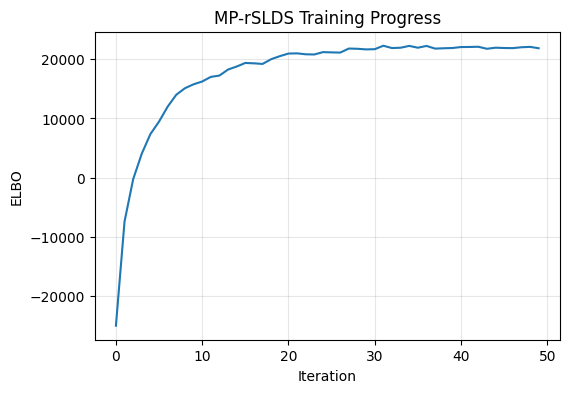


Reconstruction metrics:
MSE: 0.0913
R²: 0.9087

Model fitted successfully!
Discrete state usage: (array([0, 1, 2, 3, 4]), array([ 726, 1471,   50,   26,  727]))


In [30]:
# MP-rSLDS fitting for Multi-Region Decision-Motor RNN
import numpy as np
import matplotlib.pyplot as plt
import ssm
from ssm.extensions.mp_srslds.emissions_ext import GaussianOrthogonalCompoundEmissions
from ssm.extensions.mp_srslds.transitions_ext import StickyRecurrentOnlyTransitions
from tqdm import tqdm

# Extract trajectories from your trained RNN
print("Extracting trajectories from trained RNN...")
trajectories = extract_trajectories(trained_model, n_trials=100, noise_scale=.03)

# Prepare data for mp-rslds (concatenate evidence and motor states)
evidence_data = trajectories['evidence_states']  # [n_trials, time, 64]
motor_data = trajectories['motor_states']        # [n_trials, time, 64]
n_trials, n_time, _ = evidence_data.shape

# Concatenate into single observation matrix
data = np.concatenate([evidence_data, motor_data], axis=2)  # [n_trials, time, 128]
print(f"Data shape: {data.shape}")

# Normalize data for better fitting
data_mean = np.mean(data.reshape(-1, data.shape[-1]), axis=0)
data_std = np.std(data.reshape(-1, data.shape[-1]), axis=0) + 1e-8
data = (data - data_mean) / data_std

# MP-rSLDS Configuration
K = 5  # Number of discrete states (can sweep later)
D_evidence = 10  # Latent dimensions for evidence region
D_motor = 10     # Latent dimensions for motor region
N_evidence = 64  # Number of evidence neurons
N_motor = 64     # Number of motor neurons

# Setup population vectors
D_vec = [D_evidence, D_motor]
N_vec = [N_evidence, N_motor]
D_total = sum(D_vec)
N_total = sum(N_vec)

print(f"\nModel configuration:")
print(f"K={K} discrete states")
print(f"Evidence: {N_evidence} neurons -> {D_evidence} latents")
print(f"Motor: {N_motor} neurons -> {D_motor} latents")

# Create Gaussian emissions (for continuous RNN states)
emissions = GaussianOrthogonalCompoundEmissions(
    N=N_total, K=1, D=D_total,
    D_vec=D_vec, N_vec=N_vec)

# Create transitions
transitions = StickyRecurrentOnlyTransitions(
    K=K, D=D_total,
    l2_penalty_similarity=10,
    l1_penalty=10
)

# Create mp-rslds model
rslds = ssm.SLDS(
    N=N_total, K=K, D=D_total,
    dynamics="gaussian",
    emissions=emissions,
    transitions=transitions,
    dynamics_kwargs=dict(l2_penalty_A=100)
)

# Reshape data for SSM (combine trials)
data_flat = data.reshape(-1, N_total)  # [n_trials * time, n_neurons]

# Fit model
print(f"\nFitting mp-rslds with {K} states...")
elbos, posterior = rslds.fit(
    data_flat,
    method="laplace_em",
    variational_posterior="structured_meanfield",
    continuous_optimizer='newton',
    initialize=True,
    num_init_restarts=5,  # Reduce for speed
    num_iters=50,
    alpha=0.25
)

# Plot ELBO
plt.figure(figsize=(6, 4))
plt.plot(elbos[1:])
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.title("MP-rSLDS Training Progress")
plt.grid(True, alpha=0.3)
plt.show()

# Quick reconstruction check
preds = rslds.smooth(posterior.mean_continuous_states[0], data_flat)
mse = np.mean((data_flat - preds)**2)
r2 = 1 - np.var(data_flat - preds) / np.var(data_flat)

print(f"\nReconstruction metrics:")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

# Get discrete states
z_inferred = rslds.most_likely_states(posterior.mean_continuous_states[0], data_flat)

print(f"\nModel fitted successfully!")
print(f"Discrete state usage: {np.unique(z_inferred, return_counts=True)}")


MP-rSLDS Analysis Results

=== Reconstruction by Region ===
Evidence: MSE=0.0010, R²=0.986
Motor: MSE=0.0010, R²=0.967
Overall R²: 0.909


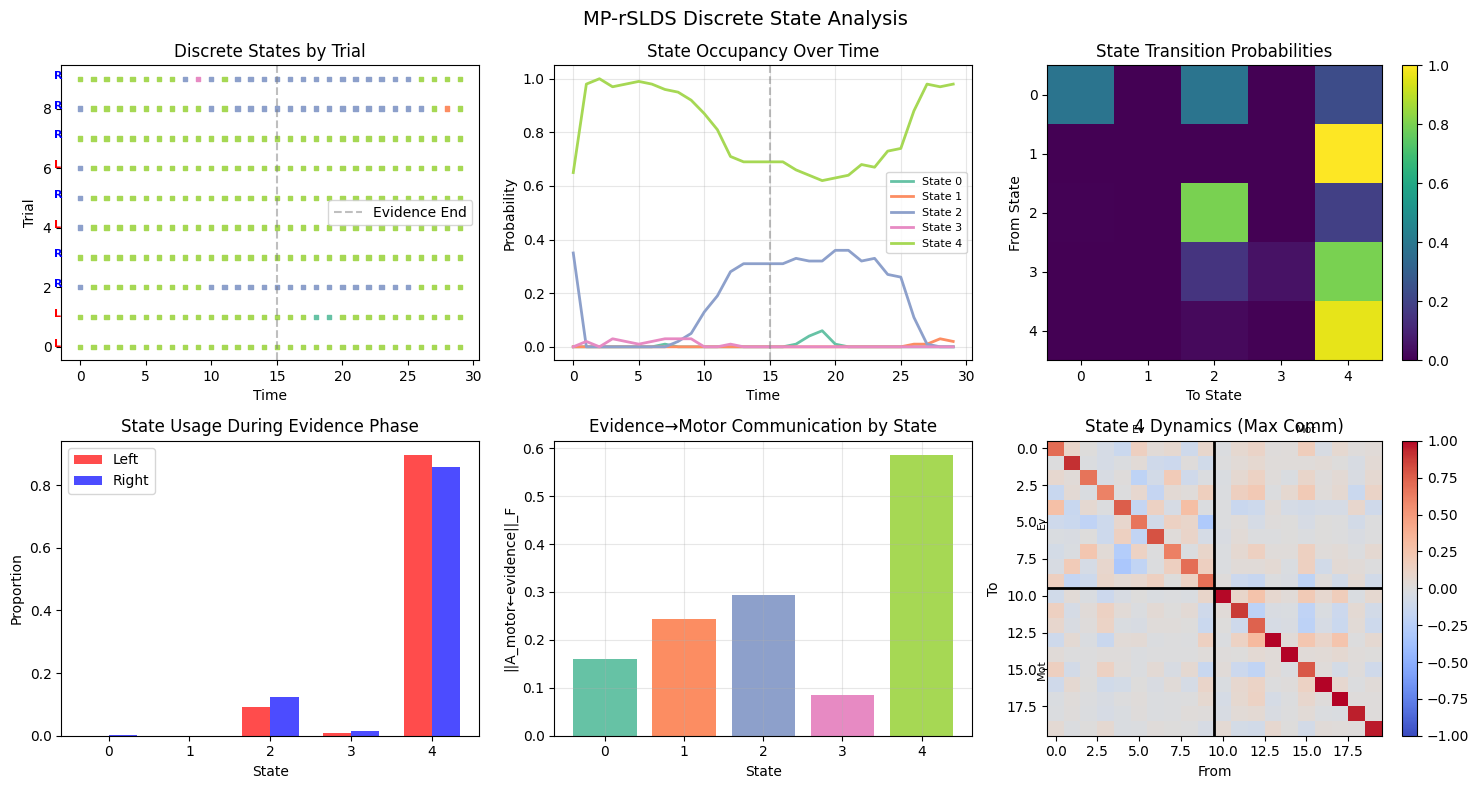

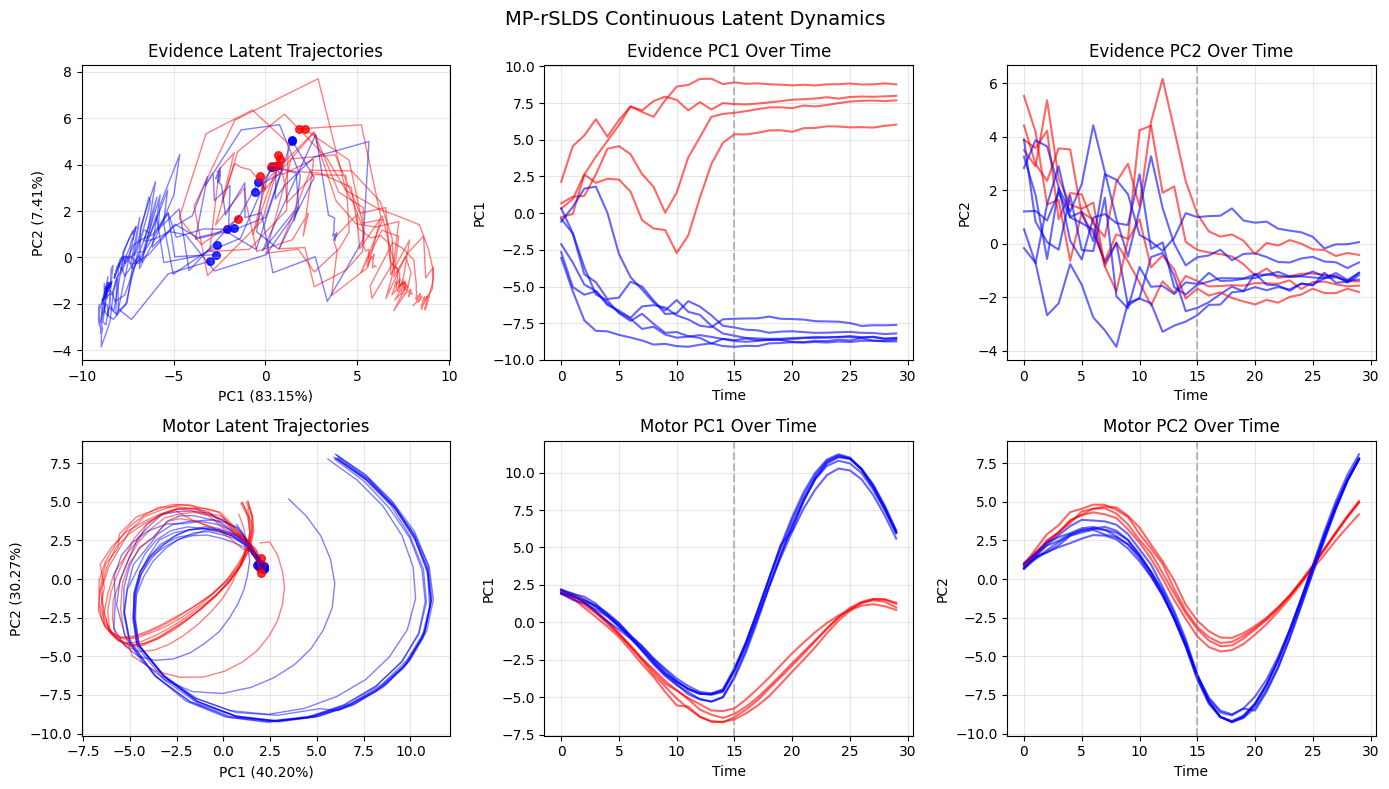


MP-rSLDS Model Summary
Number of discrete states used: 5 of 5
Evidence latent dimensions: 10
Motor latent dimensions: 10

State-dependent communication strength (Evidence→Motor):
  State 0: 0.161
  State 1: 0.244
  State 2: 0.293
  State 3: 0.086
  State 4: 0.586

Strongest communication in states: [2 4]

Latent variance explained:
  Evidence PC1-2: 0.906
  Motor PC1-2: 0.705


In [31]:
# Complete MP-rSLDS Analysis
# This cell contains all necessary definitions and can run independently after fitting

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns

# Ensure we have all necessary variables from fitting
# If any are missing, define them here
if 'z_per_trial' not in locals():
    z_per_trial = z_inferred.reshape(n_trials, n_time)

if 'D_vec' not in locals():
    D_vec = [D_evidence, D_motor]

# Set evidence phase from RNN
EVIDENCE_PHASE = 15

print("\n" + "="*50)
print("MP-rSLDS Analysis Results")
print("="*50)

# 1. Reconstruction metrics by region
data_trials = data_flat.reshape(n_trials, n_time, -1)
preds_trials = rslds.smooth(posterior.mean_continuous_states[0], data_flat).reshape(n_trials, n_time, -1)

# Denormalize
data_orig = data_trials * data_std + data_mean
preds_recon = preds_trials * data_std + data_mean

# Split regions
evidence_orig = data_orig[:, :, :64]
motor_orig = data_orig[:, :, 64:]
evidence_recon = preds_recon[:, :, :64]
motor_recon = preds_recon[:, :, 64:]

# Region-specific metrics
evidence_mse = np.mean((evidence_orig - evidence_recon)**2)
motor_mse = np.mean((motor_orig - motor_recon)**2)
evidence_r2 = 1 - np.var(evidence_orig - evidence_recon) / np.var(evidence_orig)
motor_r2 = 1 - np.var(motor_orig - motor_recon) / np.var(motor_orig)

print("\n=== Reconstruction by Region ===")
print(f"Evidence: MSE={evidence_mse:.4f}, R²={evidence_r2:.3f}")
print(f"Motor: MSE={motor_mse:.4f}, R²={motor_r2:.3f}")
print(f"Overall R²: {r2:.3f}")

# 2. Discrete states visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# State sequences
ax = axes[0, 0]
state_colors = sns.color_palette("Set2", K)
for trial in range(min(10, n_trials)):
    target = trajectories['trial_info'][trial]['target']
    colors = [state_colors[s] for s in z_per_trial[trial]]
    ax.scatter(range(n_time), [trial]*n_time, c=colors, s=10, marker='s')
    ax.text(-2, trial, 'L' if target == 0 else 'R', 
            color='red' if target == 0 else 'blue', fontweight='bold', fontsize=8)

ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.5, label='Evidence End')
ax.set_xlabel('Time')
ax.set_ylabel('Trial')
ax.set_title('Discrete States by Trial')
ax.legend()

# State occupancy over time
ax = axes[0, 1]
for state in range(K):
    state_prob = [np.mean(z_per_trial[:, t] == state) for t in range(n_time)]
    ax.plot(state_prob, label=f'State {state}', linewidth=2, color=state_colors[state])

ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Probability')
ax.set_title('State Occupancy Over Time')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# State transition matrix
ax = axes[0, 2]
trans_matrix = np.zeros((K, K))
for trial in range(n_trials):
    for t in range(n_time - 1):
        trans_matrix[z_per_trial[trial, t], z_per_trial[trial, t+1]] += 1

# Normalize rows
row_sums = trans_matrix.sum(axis=1, keepdims=True)
trans_matrix = np.divide(trans_matrix, row_sums, where=row_sums!=0)

im = ax.imshow(trans_matrix, cmap='viridis', aspect='auto', vmin=0, vmax=1)
ax.set_xlabel('To State')
ax.set_ylabel('From State')
ax.set_title('State Transition Probabilities')
plt.colorbar(im, ax=ax)

# State usage by condition (evidence phase)
ax = axes[1, 0]
left_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 0]
right_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 1]

if left_trials and right_trials:
    evidence_states_left = z_per_trial[left_trials, :EVIDENCE_PHASE].flatten()
    evidence_states_right = z_per_trial[right_trials, :EVIDENCE_PHASE].flatten()
    
    x = np.arange(K)
    width = 0.35
    
    for s in range(K):
        left_count = np.sum(evidence_states_left == s) / len(evidence_states_left)
        right_count = np.sum(evidence_states_right == s) / len(evidence_states_right)
        ax.bar(s - width/2, left_count, width, color='red', alpha=0.7)
        ax.bar(s + width/2, right_count, width, color='blue', alpha=0.7)
    
    ax.set_xlabel('State')
    ax.set_ylabel('Proportion')
    ax.set_title('State Usage During Evidence Phase')
    ax.legend(['Left', 'Right'])

# Communication strength by state
ax = axes[1, 1]
D_evidence = D_vec[0]
comm_strength = []
for k in range(K):
    A = rslds.dynamics.As[k]
    comm_block = A[D_evidence:, :D_evidence]  # Evidence to Motor
    comm_strength.append(np.linalg.norm(comm_block, 'fro'))

bars = ax.bar(range(K), comm_strength, color=state_colors)
ax.set_xlabel('State')
ax.set_ylabel('||A_motor←evidence||_F')
ax.set_title('Evidence→Motor Communication by State')
ax.grid(True, alpha=0.3)

# Example dynamics matrix
ax = axes[1, 2]
k_show = np.argmax(comm_strength)  # Show state with strongest communication
A = rslds.dynamics.As[k_show]
im = ax.imshow(A, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.axhline(y=D_evidence-0.5, color='black', linewidth=2)
ax.axvline(x=D_evidence-0.5, color='black', linewidth=2)
ax.set_title(f'State {k_show} Dynamics (Max Comm)')
ax.set_xlabel('From')
ax.set_ylabel('To')

# Add labels
ax.text(D_evidence/2, -1, 'Ev', ha='center', fontsize=8)
ax.text(D_evidence + D_vec[1]/2, -1, 'Mot', ha='center', fontsize=8)
ax.text(-0.5, D_evidence/2, 'Ev', ha='right', rotation=90, va='center', fontsize=8)
ax.text(-0.5, D_evidence + D_vec[1]/2, 'Mot', ha='right', rotation=90, va='center', fontsize=8)

plt.colorbar(im, ax=ax)

plt.suptitle('MP-rSLDS Discrete State Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Continuous latent dynamics
latents = posterior.mean_continuous_states[0].reshape(n_trials, n_time, -1)
evidence_latents = latents[:, :, :D_evidence]
motor_latents = latents[:, :, D_evidence:]

# PCA on latents
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Evidence latents PCA
evidence_flat = evidence_latents.reshape(-1, D_evidence)
pca_ev = PCA(n_components=min(3, D_evidence))
pca_ev.fit(evidence_flat)
evidence_pca = np.array([pca_ev.transform(evidence_latents[i]) for i in range(n_trials)])

# Evidence trajectories
ax = axes[0, 0]
for trial in range(min(20, n_trials)):
    target = trajectories['trial_info'][trial]['target']
    color = 'red' if target == 0 else 'blue'
    ax.plot(evidence_pca[trial, :, 0], evidence_pca[trial, :, 1], 
           color=color, alpha=0.5, linewidth=1)
    # Mark start
    ax.scatter(evidence_pca[trial, 0, 0], evidence_pca[trial, 0, 1],
              color=color, s=30, marker='o', alpha=0.8)

ax.set_xlabel(f'PC1 ({pca_ev.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca_ev.explained_variance_ratio_[1]:.2%})')
ax.set_title('Evidence Latent Trajectories')
ax.grid(True, alpha=0.3)

# Evidence PC1 over time
ax = axes[0, 1]
for trial in range(min(10, n_trials)):
    target = trajectories['trial_info'][trial]['target']
    color = 'red' if target == 0 else 'blue'
    ax.plot(evidence_pca[trial, :, 0], color=color, alpha=0.6, linewidth=1.5)

ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('PC1')
ax.set_title('Evidence PC1 Over Time')
ax.grid(True, alpha=0.3)

# Evidence PC2 over time
ax = axes[0, 2]
for trial in range(min(10, n_trials)):
    target = trajectories['trial_info'][trial]['target']
    color = 'red' if target == 0 else 'blue'
    ax.plot(evidence_pca[trial, :, 1], color=color, alpha=0.6, linewidth=1.5)

ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('PC2')
ax.set_title('Evidence PC2 Over Time')
ax.grid(True, alpha=0.3)

# Motor latents PCA
motor_flat = motor_latents.reshape(-1, D_vec[1])
pca_mot = PCA(n_components=min(3, D_vec[1]))
pca_mot.fit(motor_flat)
motor_pca = np.array([pca_mot.transform(motor_latents[i]) for i in range(n_trials)])

# Motor trajectories
ax = axes[1, 0]
for trial in range(min(20, n_trials)):
    target = trajectories['trial_info'][trial]['target']
    color = 'red' if target == 0 else 'blue'
    ax.plot(motor_pca[trial, :, 0], motor_pca[trial, :, 1], 
           color=color, alpha=0.5, linewidth=1)
    ax.scatter(motor_pca[trial, 0, 0], motor_pca[trial, 0, 1],
              color=color, s=30, marker='o', alpha=0.8)

ax.set_xlabel(f'PC1 ({pca_mot.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca_mot.explained_variance_ratio_[1]:.2%})')
ax.set_title('Motor Latent Trajectories')
ax.grid(True, alpha=0.3)

# Motor PC1 over time
ax = axes[1, 1]
for trial in range(min(10, n_trials)):
    target = trajectories['trial_info'][trial]['target']
    color = 'red' if target == 0 else 'blue'
    ax.plot(motor_pca[trial, :, 0], color=color, alpha=0.6, linewidth=1.5)

ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('PC1')
ax.set_title('Motor PC1 Over Time')
ax.grid(True, alpha=0.3)

# Motor PC2 over time
ax = axes[1, 2]
for trial in range(min(10, n_trials)):
    target = trajectories['trial_info'][trial]['target']
    color = 'red' if target == 0 else 'blue'
    ax.plot(motor_pca[trial, :, 1], color=color, alpha=0.6, linewidth=1.5)

ax.axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('PC2')
ax.set_title('Motor PC2 Over Time')
ax.grid(True, alpha=0.3)

plt.suptitle('MP-rSLDS Continuous Latent Dynamics', fontsize=14)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*50)
print("MP-rSLDS Model Summary")
print("="*50)
print(f"Number of discrete states used: {len(np.unique(z_inferred))} of {K}")
print(f"Evidence latent dimensions: {D_vec[0]}")
print(f"Motor latent dimensions: {D_vec[1]}")
print(f"\nState-dependent communication strength (Evidence→Motor):")
for k in range(K):
    print(f"  State {k}: {comm_strength[k]:.3f}")
print(f"\nStrongest communication in states: {np.argsort(comm_strength)[-2:]}")
print(f"\nLatent variance explained:")
print(f"  Evidence PC1-2: {pca_ev.explained_variance_ratio_[:2].sum():.3f}")
print(f"  Motor PC1-2: {pca_mot.explained_variance_ratio_[:2].sum():.3f}")

In [49]:
# ================================================
# MP-rSLDS TEST EVALUATION (200 trials)  
# ================================================
print("\n" + "="*50)
print("MP-rSLDS TEST EVALUATION")
print("="*50)

# Use same test trajectories for fair comparison
test_data = np.concatenate([test_evidence, test_motor], axis=2)  # [200, time, 128]
test_data_norm = (test_data - data_mean) / data_std
test_data_flat = test_data_norm.reshape(-1, N_total).astype(np.float64)

print("Generating MP-rSLDS predictions...")

# Generate MP-rSLDS predictions (minimal fitting iterations)
test_elbos, test_posterior = rslds.fit(
    test_data_flat,
    method="laplace_em",
    variational_posterior="structured_meanfield", 
    continuous_optimizer='newton',
    initialize=False,  # Use existing parameters
    num_iters=5,       # Just infer states
    alpha=0.25
)

# Get predictions
test_preds = rslds.smooth(test_posterior.mean_continuous_states[0], test_data_flat)
test_preds_trials = test_preds.reshape(200, -1, N_total)

# Denormalize predictions
test_preds_orig = test_preds_trials * data_std + data_mean

# Split regions 
pred_ev_rslds = test_preds_orig[:, :, :64]   # Evidence region
pred_mt_rslds = test_preds_orig[:, :, 64:]   # Motor region
true_ev_rslds = test_evidence
true_mt_rslds = test_motor

# MSE
mse_ev_rslds = np.mean((true_ev_rslds - pred_ev_rslds) ** 2)
mse_mt_rslds = np.mean((true_mt_rslds - pred_mt_rslds) ** 2)
mse_total_rslds = np.mean((test_data - test_preds_orig) ** 2)

# R²
var_ev_rslds = np.var(true_ev_rslds)
var_mt_rslds = np.var(true_mt_rslds)
var_total_rslds = np.var(test_data)
r2_ev_rslds = 1 - np.var(true_ev_rslds - pred_ev_rslds) / var_ev_rslds
r2_mt_rslds = 1 - np.var(true_mt_rslds - pred_mt_rslds) / var_mt_rslds
r2_total_rslds = 1 - np.var(test_data - test_preds_orig) / var_total_rslds

print("\n=== MP-rSLDS TEST METRICS ===")
print(f"Evidence: MSE={mse_ev_rslds:.6f}, R²={r2_ev_rslds:.4f}")
print(f"Motor:    MSE={mse_mt_rslds:.6f}, R²={r2_mt_rslds:.4f}")  
print(f"Total:    MSE={mse_total_rslds:.6f}, R²={r2_total_rslds:.4f}")



MP-rSLDS TEST EVALUATION
Generating MP-rSLDS predictions...


  0%|          | 0/5 [00:00<?, ?it/s]


=== MP-rSLDS TEST METRICS ===
Evidence: MSE=0.001003, R²=0.9863
Motor:    MSE=0.001028, R²=0.9668
Total:    MSE=0.001016, R²=0.9806


In [46]:
def save_mprslds_data(rslds, trajectories, posterior, elbos, data_mean, data_std,
                      K, D_vec, N_vec, data_flat, preds, cache_dir="cache/mprslds_fit_dmotor_rnn"):
    """Save MP-RSLDS model and data to cache"""
    import os
    import pickle
    import numpy as np
    
    os.makedirs(cache_dir, exist_ok=True)
    
    # Save model
    model_path = os.path.join(cache_dir, "mprslds_model.pkl")
    with open(model_path, 'wb') as f:
        pickle.dump(rslds, f)
    
    # Save posterior
    posterior_path = os.path.join(cache_dir, "mprslds_posterior.pkl")
    with open(posterior_path, 'wb') as f:
        pickle.dump(posterior, f)
    
    # Save data and predictions
    data_path = os.path.join(cache_dir, "mprslds_data.npz")
    np.savez(data_path,
             trajectories_evidence=trajectories['evidence_states'],
             trajectories_motor=trajectories['motor_states'],
             data_flat=data_flat,
             predictions=preds,
             data_mean=data_mean,
             data_std=data_std,
             elbos=elbos,
             K=K,
             D_vec=D_vec,
             N_vec=N_vec)
    
    print(f"Saved MP-RSLDS to {cache_dir}")

def load_mprslds_data(cache_dir="cache/mprslds_fit_dmotor_rnn"):
    """Load cached MP-RSLDS model and data if available"""
    import os
    import pickle
    import numpy as np
    
    model_path = os.path.join(cache_dir, "mprslds_model.pkl")
    posterior_path = os.path.join(cache_dir, "mprslds_posterior.pkl")
    data_path = os.path.join(cache_dir, "mprslds_data.npz")
    
    if os.path.exists(model_path) and os.path.exists(posterior_path) and os.path.exists(data_path):
        print("Loading cached MP-RSLDS model and data...")
        
        # Load model
        with open(model_path, 'rb') as f:
            rslds = pickle.load(f)
        
        # Load posterior
        with open(posterior_path, 'rb') as f:
            posterior = pickle.load(f)
        
        # Load data
        data = np.load(data_path)
        trajectories = {
            'evidence_states': data['trajectories_evidence'],
            'motor_states': data['trajectories_motor']
        }
        data_flat = data['data_flat']
        predictions = data['predictions']
        data_mean = data['data_mean']
        data_std = data['data_std']
        elbos = data['elbos']
        K = int(data['K'])
        D_vec = list(data['D_vec'])
        N_vec = list(data['N_vec'])
        
        print(f"Loaded MP-RSLDS with K={K}, {len(elbos)} training iterations")
        
        return {
            'rslds': rslds,
            'trajectories': trajectories,
            'posterior': posterior,
            'predictions': predictions,
            'data_flat': data_flat,
            'data_mean': data_mean,
            'data_std': data_std,
            'elbos': elbos,
            'K': K,
            'D_vec': D_vec,
            'N_vec': N_vec
        }
    
    return None

In [48]:
# After training, save everything including predictions
save_mprslds_data(
    rslds=rslds,
    trajectories=trajectories,
    posterior=posterior,
    elbos=elbos,
    data_mean=data_mean,
    data_std=data_std,
    K=K,
    D_vec=D_vec,
    N_vec=N_vec,
    data_flat=data_flat,
    preds=preds  # Pass the predictions computed during training
)

# Later, load everything back
results = load_mprslds_data()
if results:
    rslds = results['rslds']
    trajectories = results['trajectories']
    posterior = results['posterior']
    predictions = results['predictions']
    data_flat = results['data_flat']
    data_mean = results['data_mean']
    data_std = results['data_std']
    elbos = results['elbos']
    K = results['K']
    D_vec = results['D_vec']
    N_vec = results['N_vec']
    
    # Extract individual trajectory components
    evidence_states = trajectories['evidence_states']
    motor_states = trajectories['motor_states']
    
    # Compute reconstruction metrics
    mse = np.mean((data_flat - predictions)**2)
    r2 = 1 - np.var(data_flat - predictions) / np.var(data_flat)
    
    # Get inferred discrete states
    z_inferred = rslds.most_likely_states(posterior.mean_continuous_states[0], data_flat)
    
    # Get continuous latent states
    x_inferred = posterior.mean_continuous_states[0]
    
    print(f"\nLoaded MP-RSLDS Summary:")
    print(f"  K={K} discrete states")
    print(f"  Evidence: {N_vec[0]} neurons -> {D_vec[0]} latents")
    print(f"  Motor: {N_vec[1]} neurons -> {D_vec[1]} latents")
    print(f"  MSE: {mse:.4f}")
    print(f"  R²: {r2:.4f}")
    print(f"  State usage: {np.unique(z_inferred, return_counts=True)}")

Saved MP-RSLDS to cache/mprslds_fit_dmotor_rnn
Loading cached MP-RSLDS model and data...
Loaded MP-RSLDS with K=5, 51 training iterations

Loaded MP-RSLDS Summary:
  K=5 discrete states
  Evidence: 64 neurons -> 10 latents
  Motor: 64 neurons -> 10 latents
  MSE: 0.0913
  R²: 0.9087
  State usage: (array([0, 1, 2, 3, 4]), array([ 523, 1044,  354,  443,  636]))
